In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
aln = ALNModel()

# plot uncontrolled dynamics, controlled dynamics
def plot_control(control_, target_ = aln.getZeroTarget(), filename = 'control_aln.png'):
    
    # no control
    aln.run()
    output_vars = aln.output_vars
    control_vars = aln.control_input_vars
    control_time_exc = - np.ones((2))
    control_time_inh = - np.ones((2))
    cntrl_limit_scaled = 10 * 1e-3
    cntrl_limit = cntrl_limit_scaled * 5. # 1e-3 nA (factor 5 because capacitance)
    
    
    
    for t in range(len(aln.t)):
        if (np.abs(control_[0,0,t]) > cntrl_limit and control_time_exc[0] == -1):
            control_time_exc[0] = aln.params.dt * t
        if (np.abs(control_[0,1,t]) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[0] = aln.params.dt * t
        if (control_time_exc[0] != -1 and control_time_inh[0] != -1):
            break
    for t in range(len(aln.t)-1, 0, -1):
        if (np.abs(control_[0,0,t]) > cntrl_limit and control_time_exc[1] == -1):
            control_time_exc[1] = aln.params.dt * t
        if (np.abs(control_[0,1,t]) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[1] = aln.params.dt * t
        if (control_time_exc[1] != -1 and control_time_inh[1] != -1):
            break

    fig, ax = plt.subplots(3, 3, figsize=(21, 15), linewidth=8, edgecolor='grey')
    plt.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.3, hspace=0.3)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]', 'Adaptation current [pA]']
    y_labels_control = ['Control exc. [nA]', 'Control inh. [nA]']
    sim_legend = ['Rate', 'Rate', 'Adaptation current']
    target_legend = ['Target']
    cntrl_time_legend = ['Control > {} pA'.format(cntrl_limit_scaled * 1000)]
    
    for i in range(len(output_vars)):
        ax[0,i].plot(aln.t, aln[output_vars[i]][0,:], label=sim_legend[i])
        ax[0,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[0,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[0,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    aln.run(control=control_)

    for i in range(len(output_vars)):
        ax[1,i].plot(aln.t, aln[output_vars[i]][0,:], label=sim_legend[i])
        ax[1,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[1,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[1,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    for i in range(len(control_vars)):
        ax[2,i].plot(aln.t, control_[0,i,:]/5.) # divide by five to take into account capacitance
        ax[2,i].set(xlabel='t [ms]', ylabel=y_labels_control[i])
    ax[2,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[2,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])

    if (target.any() != 0.):
        ax[0,0].plot(aln.t, target[0,0,:], '--', label=target_legend[0])
        ax[1,0].plot(aln.t, target[0,0,:], '--', label=target_legend[0])
        ax[0,1].plot(aln.t, target[0,1,:], '--', label=target_legend[0])
        ax[1,1].plot(aln.t, target[0,1,:], '--', label=target_legend[0])
        
        state = aln.getZeroState()
        for i in range(len(output_vars)):
            state[:,i,:] = aln[output_vars[i]][:,:]
        cost = aln.cost(state, target_, control_)
        
        ax[2,2].plot(aln.t, cost)
        ax[2,2].set(xlabel='t [ms]', ylabel='Cost')
        #ax[2,2].plot([-2.75, 1.01], [1.03, 1.03], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)
        #ax[2,2].plot([-0.2, -0.2], [3.45, -0.15], transform=ax[2,2].transAxes, clip_on=False, c='grey', linewidth = 3)

    for i in range(3):
        for j in range(2):
            ax[i,j].legend(loc='upper right')
            
    rows = ['Uncontrolled', 'Controlled']
            
    for a, row in zip(ax[:,0], rows):
        a.annotate(row, xy=(-0.05, 0.5), xytext=(-a.yaxis.labelpad - 15, 0), rotation = 90,
                xycoords=a.yaxis.label, textcoords='offset points', size=20, ha='right', va='center', weight='bold')
        
    cols = ['Excitatory', 'Inhibitory']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.05), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=20, ha='center', va='baseline', weight='bold')
    
    plt.tight_layout()
    plt.savefig(filename)
    
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

In [76]:
def plot_control_network(control_, t_sim_, t_sim_pre_, t_sim_post_, initial_params_,
                         target_ = aln.getZeroTarget(), filename = 'control_aln.png'):
    
    # no control
    aln.run()
    output_vars = aln.output_vars
    control_vars = aln.control_input_vars
    control_time_exc = - np.ones((2))
    control_time_inh = - np.ones((2))
    cntrl_limit_scaled = 10 * 1e-3
    cntrl_limit = cntrl_limit_scaled * 5. # 1e-3 nA (factor 5 because capacitance)
    
    dt = aln.params.dt
    aln.params.duration = (control_.shape[2] - 1.) * dt
    i1 = int(round(t_sim_pre_/dt, 1))
    i2 = int(round(t_sim_post_/dt, 1))
    
        
    init_vars = aln.init_vars
    for iv in range(len(init_vars)):
        for n in range(aln.params.N):
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][n,0] = initial_params_[n,iv]
            else:
                aln.params[init_vars[iv]][n] = initial_params_[n,iv]
                
    # no control
    aln.run()
    
    for t in range(len(aln.t)):
        if (np.abs(any(control_[:,0,t])) > cntrl_limit and control_time_exc[0] == -1):
            control_time_exc[0] = aln.params.dt * t
        if (np.abs(any(control_[:,1,t])) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[0] = aln.params.dt * t
        if (control_time_exc[0] != -1 and control_time_inh[0] != -1):
            break
    for t in range(len(aln.t)-1, 0, -1):
        if (np.abs(any(control_[:,0,t])) > cntrl_limit and control_time_exc[1] == -1):
            control_time_exc[1] = aln.params.dt * t
        if (np.abs(any(control_[:,1,t])) > cntrl_limit and control_time_inh[1] == -1):
            control_time_inh[1] = aln.params.dt * t
        if (control_time_exc[1] != -1 and control_time_inh[1] != -1):
            break

    fig, ax = plt.subplots(3, 2, figsize=(21, 15), linewidth=8, edgecolor='grey')
    plt.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.3, hspace=0.3)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]', 'Adaptation current [pA]']
    y_labels_control = ['Control exc. [nA]', 'Control inh. [nA]']
    sim_legend = ['Rate #{}', 'Rate #{}', 'Adaptation current #{}']
    target_legend = ['Target #{}']
    cntrl_time_legend = ['Control > {} pA'.format(cntrl_limit_scaled * 1000)]
    
    for i in range(len(output_vars) - 1):
        for n in range(aln.params["N"]):
            ax[0,i].plot(aln.t, aln[output_vars[i]][n,:], label=sim_legend[i].format(n))
        ax[0,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[0,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[0,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    aln.run(control=control_)

    for i in range(len(output_vars) - 1):
        for n in range(aln.params["N"]):
            ax[1,i].plot(aln.t, aln[output_vars[i]][n,:], label=sim_legend[i].format(n))
        ax[1,i].set(xlabel='t [ms]', ylabel=y_labels_rates[i])
    ax[1,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[1,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    
    for i in range(len(control_vars)):
        for n in range(aln.params["N"]):
            ax[2,i].plot(aln.t, control_[n,i,:]/5.) # divide by five to take into account capacitance
        ax[2,i].set(xlabel='t [ms]', ylabel=y_labels_control[i])
    ax[2,0].axvspan(control_time_exc[0], control_time_exc[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])
    ax[2,1].axvspan(control_time_inh[0], control_time_inh[1], facecolor='0.1', alpha=0.2, zorder=-100,
                    label=cntrl_time_legend[0])

    if (target_.any() != 0.):
        if (i2 == 0):
            ax[0,0].plot(aln.t[i1:], target_[0,0,:], '--', label=target_legend[0])
            ax[1,0].plot(aln.t[i1:], target_[0,0,:], '--', label=target_legend[0])
            ax[0,1].plot(aln.t[i1:], target_[0,1,:], '--', label=target_legend[0])
            ax[1,1].plot(aln.t[i1:], target_[0,1,:], '--', label=target_legend[0])
        else:
            ax[0,0].plot(aln.t[i1:-i2], target_[0,0,:], '--', label=target_legend[0])
            ax[1,0].plot(aln.t[i1:-i2], target_[0,0,:], '--', label=target_legend[0])
            ax[0,1].plot(aln.t[i1:-i2], target_[0,1,:], '--', label=target_legend[0])
            ax[1,1].plot(aln.t[i1:-i2], target_[0,1,:], '--', label=target_legend[0])

    for i in range(3):
        for j in range(2):
            ax[i,j].legend(loc='upper right')
            
    rows = ['Uncontrolled', 'Controlled']
            
    for a, row in zip(ax[:,0], rows):
        a.annotate(row, xy=(-0.05, 0.5), xytext=(-a.yaxis.labelpad - 15, 0), rotation = 90,
                xycoords=a.yaxis.label, textcoords='offset points', size=20, ha='right', va='center', weight='bold')
        
    cols = ['Excitatory', 'Inhibitory']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.05), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=20, ha='center', va='baseline', weight='bold')
    
    plt.tight_layout()
    plt.savefig(filename)

[[8.3967e-05 2.6108e+01]
 [3.7674e+01 9.4217e+01]]


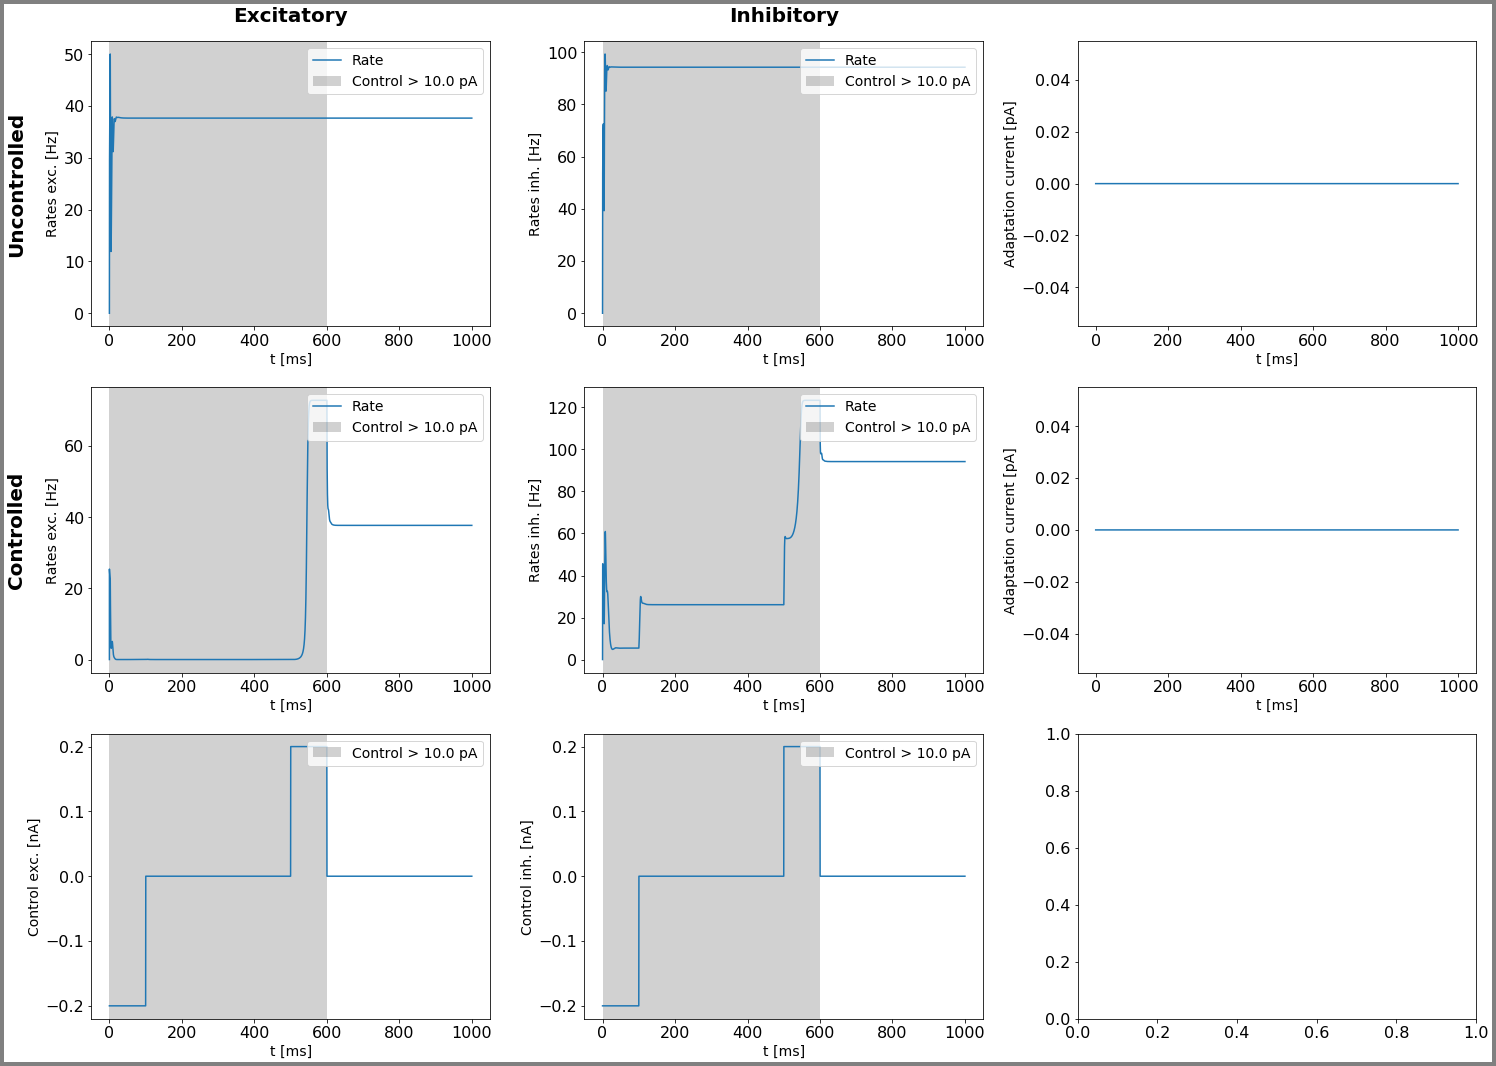

In [88]:
aln = ALNModel()

aln.params['duration'] = 1000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

output = aln.output_vars
state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,4500:4501]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,4500:4501]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,7500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,7500:]) #high state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

plot_control(control0)

low state vars =  [ 8.3967e-05  2.6108e+01 -3.3406e-01  1.0431e+00  0.0000e+00  1.6586e-05
  7.9821e-01  1.5501e-05  8.8839e-01  1.0238e-06  2.6207e-03  8.9428e-07
  1.9512e-03  7.2915e-89  5.4686e-89]


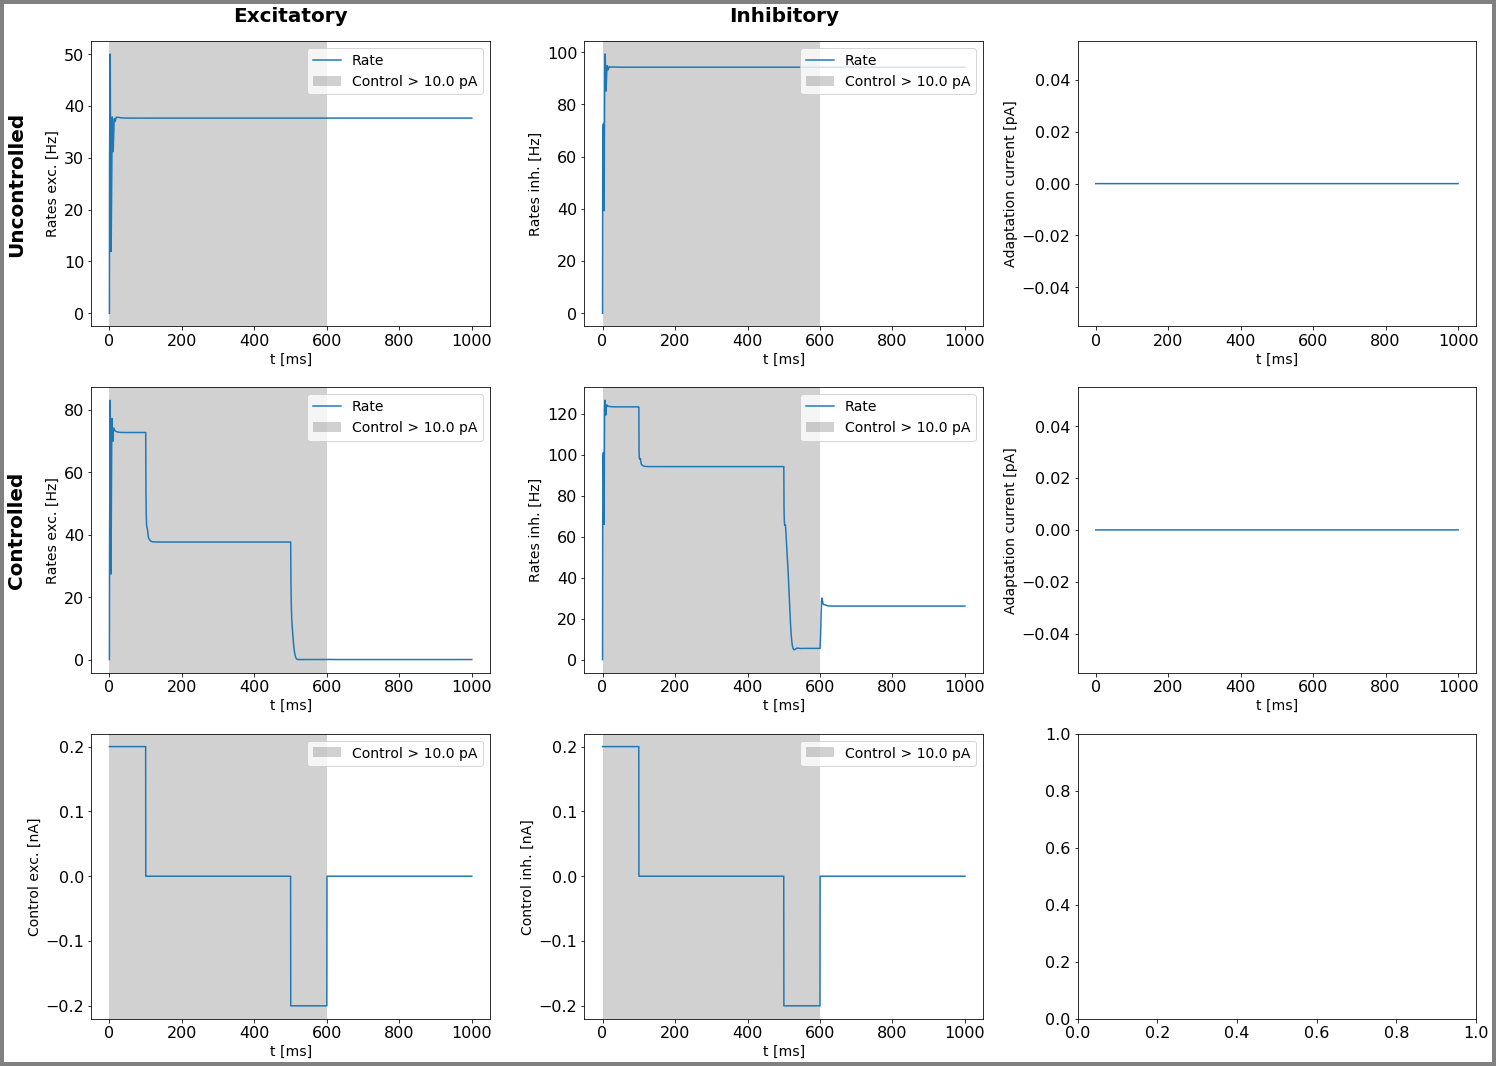

In [89]:
control0 = aln.getZeroControl()
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plot_control(control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

In [90]:
aln = ALNModel()
output = aln.output_vars

# 1 impacts 2
c_mat = np.array([[0, 0], [1, 0]])

# 2 impacts 1
#c_mat = np.array([[0, 1], [0, 0]])

# 1 impacts 2, 2 impacts 1
#c_mat = np.array([[0, 1], [1, 0]])

c_scheme = np.zeros((len(output), len(output) ))
c_scheme[0,0] = 1.

fiber_matrix = np.zeros((len(c_mat), len(c_mat)))
aln = ALNModel(Cmat = c_mat, Dmat = fiber_matrix)

u_mat = np.identity(aln.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

for init in aln.init_vars:
    aln.params[init] = np.zeros(aln.params[init].shape)

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0  

In [93]:
aln.params.c_gl = 0.0
aln.params.ext_exc_current = np.array([[2.3], [2.3]])
aln.params.ext_inh_current = np.array([[2.5], [2.5]])

init_params = np.zeros(( aln.params.N, len(init_vars) ))
for v in range(len(init_vars)):
    init_params[0,v] = high_state_vars[v]
    init_params[1,v] = low_state_vars[v]

set cost params


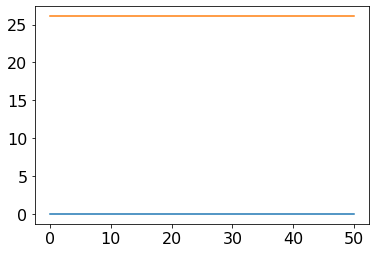

In [95]:
dur = 50
dur_pre = 20
dur_post = 20
aln.params.duration = dur

max_it = 20
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 1000.
test_step = 1e-10

opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

target = aln.getZeroTarget()
target[:,0,:] = steady_rates[1,0]
target[:,1,:] = steady_rates[1,1]

cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv, sv in zip(range(len(init_vars)), range(len(state_vars))):
    if state_vars[sv] in init_vars[iv]:
        for n in range(aln.params.N):
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][n,0] = init_params[n,sv]
            else:
                aln.params[init_vars[iv]][n] = init_params[n,sv]
                
aln.run()
plt.plot(aln.t, aln.rates_exc[1,:])
plt.plot(aln.t, aln.rates_inh[1,:])

In [96]:
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

control0 = aln.getZeroControl()
#control0[1,0,:] = 2.3
#control0[1,1,:] = 2.5

for iv, sv in zip(range(len(init_vars)), range(len(state_vars))):
    if state_vars[sv] in init_vars[iv]:
        for n in range(aln.params.N):
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][n,0] = init_params[n,sv]
            else:
                aln.params[init_vars[iv]][n] = init_params[n,sv]

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

resultA = {"Opt_control": A2_bestControlA,
          "Opt_state": A2_bestStateA,
          "costArray": A2_costA,
          "runtimeArray": A2_runtimeA,    
}

dump_dicts = [opt_params, aln.params, resultA]
pickle.dump( dump_dicts, open( "A.p", "wb" ) )

set cost params
start ind =  1
RUN  0 , total integrated cost:  151757.5759524593
change helped, counter =  1
change helped, counter =  1
RUN  1 , total integrated cost:  7698.33689701222
RUN  2 , total integrated cost:  6417.585904315296
RUN  3 , total integrated cost:  4687.684801158804
change helped, counter =  2
change helped, counter =  2
RUN  4 , total integrated cost:  4456.086519956006
RUN  5 , total integrated cost:  4253.69735048801
RUN  6 , total integrated cost:  4164.595033198884
RUN  7 , total integrated cost:  4087.481847335345
RUN  8 , total integrated cost:  4004.395501880733
RUN  9 , total integrated cost:  3920.5532471321585
RUN  10 , total integrated cost:  3826.9792315686846
RUN  11 , total integrated cost:  3727.733575482045
RUN  12 , total integrated cost:  3632.0125447854666
RUN  13 , total integrated cost:  3557.9505682962035
RUN  14 , total integrated cost:  3512.6641377367537
RUN  15 , total integrated cost:  3489.1505373844243
RUN  16 , total integrated cost

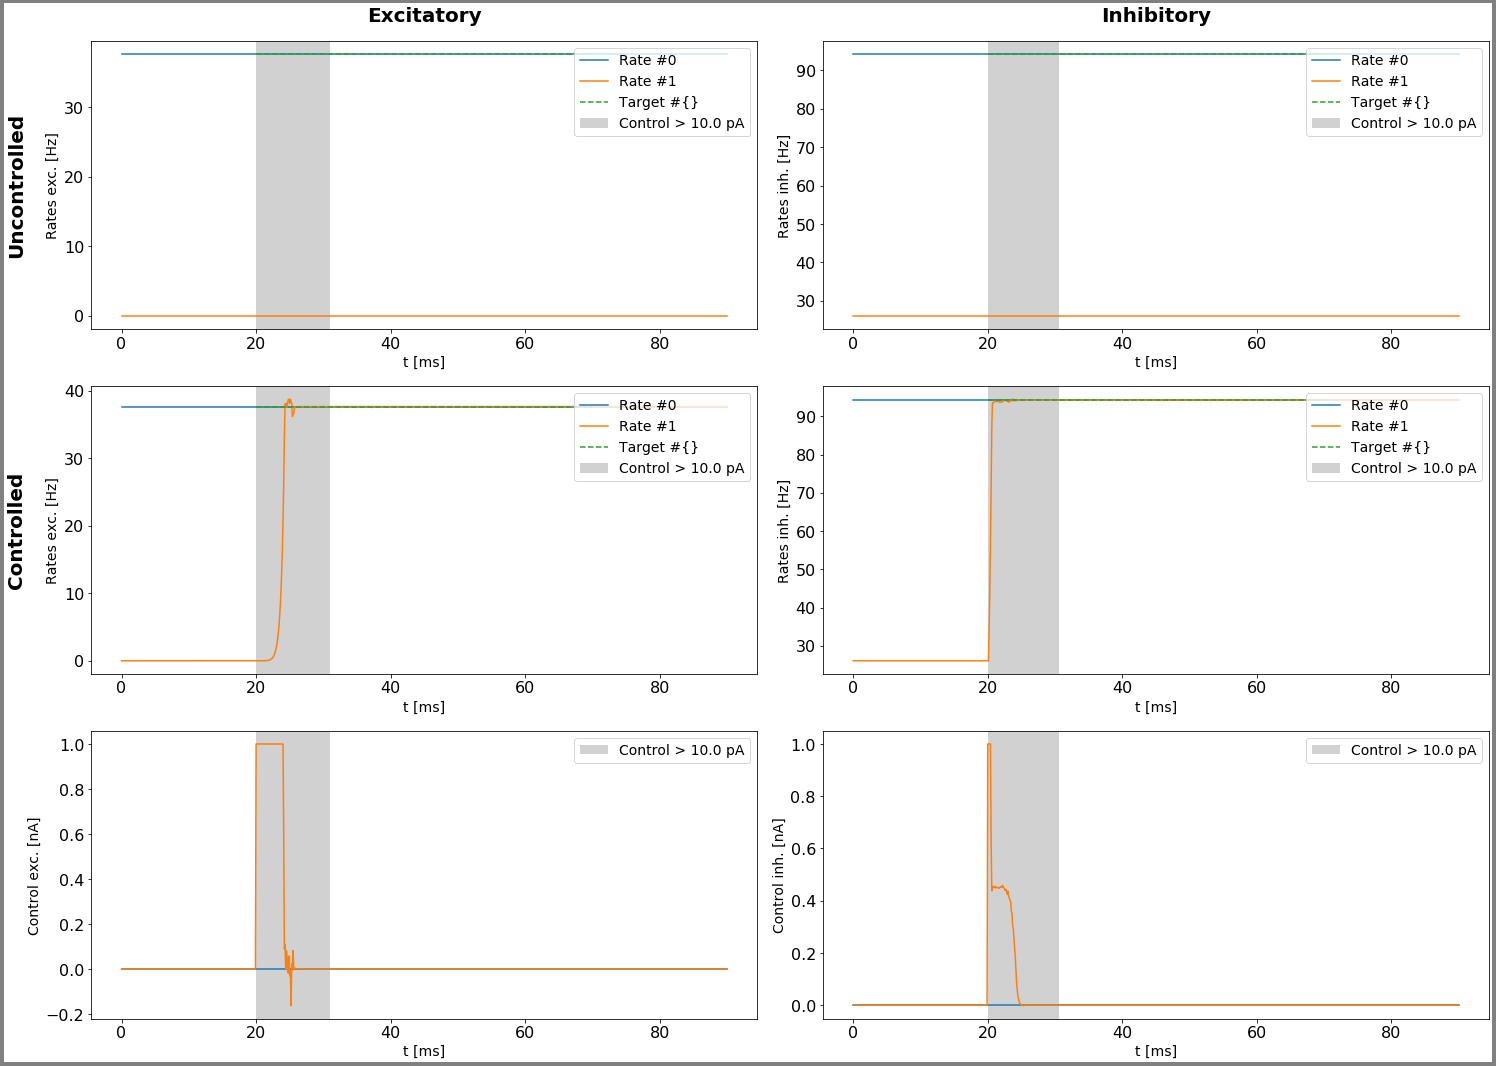

In [97]:
plot_control_network(A2_bestControlA, dur, dur_pre, dur_post, init_params, target, filename = 'networkA.png')